In [1]:
#Milestone 3: Feature Prioritization using RICE Framework
#Loading necessary libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print("="*60)
print("Step 0: LOADING M2 OUTPUTS")
print("="*60)

feature_mentions = pd.read_csv("feature_mentions.csv")
sentiment_by_feature = pd.read_csv("sentiment_by_feature.csv")
competitive_analysis = pd.read_csv("competitive_analysis.csv")
gap_analysis = pd.read_csv("gap_analysis.csv") #competitive gaps summary 
feature_requests = pd.read_csv("feature_request.csv") #aggregated request list
preprocessed = pd.read_csv("preprocessed.csv")

print("loaded data:")
print("Feature mentions shape:", feature_mentions.shape)
print(feature_mentions.head())

print("\nSentiment by feature shape:", sentiment_by_feature.shape)
print(sentiment_by_feature.head())

print("\n Competitive analysis shape:", competitive_analysis.shape)
print(competitive_analysis.head())

print("\nGap analysis shape:", gap_analysis.shape)
print(gap_analysis.head())

print("\nFeature requests shape:", feature_requests.shape)
print(feature_requests.head())

print("\nPreprocessed shape:", preprocessed.shape)
print(preprocessed.head())

Step 0: LOADING M2 OUTPUTS
loaded data:
Feature mentions shape: (10, 3)
    Feature Category  Mention Count  Percentage
0  Calorie/Nutrition             83       49.40
1   Workout Tracking             54       32.14
2     User Interface             43       25.60
3  Progress Tracking             40       23.81
4   Sync/Integration             29       17.26

Sentiment by feature shape: (10, 7)
    Feature Category  Mention Count  Avg Sentiment  Positive %  Negative %  \
0       Offline Mode              1          0.806       100.0         0.0   
1     User Interface             43          0.663        88.4         7.0   
2  Progress Tracking             40          0.645        90.0        10.0   
3         Motivation             10          0.617        90.0        10.0   
4  Calorie/Nutrition             83          0.609        85.5        10.8   

   Neutral %  Net Sentiment  
0        0.0          100.0  
1        4.7           81.4  
2        0.0           80.0  
3        0.0  

In [3]:
print("="*60)
print("Step 1: CONSOLIDATING FEATURE LIST FROM M2 ANALYSIS")
print("="*60)

#using feature categories from sentiment_by_feature and feature_mentions as base
features_list = sentiment_by_feature['Feature Category'].tolist()
print("\n Consolidated features from M2:", features_list)

#Creating comprehensive feature list (10-12 features as per guidelines)
#Combining existing features and adding common request from fitness apps based on analysis
#Adding specific requests: Rest times, Dark mode, Wearable integration, Custom workout, etc.

full_features = [
    "Offline Mode",
    "Wearable Integration (Apple Watch/Fitbit)",
    "Rest Timer Between Sets",
    "Dark Mode UI",
    "Custom Workout Builder",
    "Social Features (Challenges)",
    "Progress Photo Tracking",
    "Advanced Nutrition/Meal Planning",
    "Water Intake Tracker",
    "Export Data (CSV/PDF)",
    "Video Exercise Demonstrations",
    "Voice-Guided Workouts"
]

print("\nFull consolidated feature list (12 features):")
for i, f in enumerate(full_features, 1):
    print(f"{i}. {f}")

Step 1: CONSOLIDATING FEATURE LIST FROM M2 ANALYSIS

 Consolidated features from M2: ['Offline Mode', 'User Interface', 'Progress Tracking', 'Motivation', 'Calorie/Nutrition', 'Premium/Price', 'Workout Tracking', 'Customer Support', 'Sync/Integration', 'Bugs/Technical']

Full consolidated feature list (12 features):
1. Offline Mode
2. Wearable Integration (Apple Watch/Fitbit)
3. Rest Timer Between Sets
4. Dark Mode UI
5. Custom Workout Builder
6. Social Features (Challenges)
7. Progress Photo Tracking
8. Advanced Nutrition/Meal Planning
9. Water Intake Tracker
10. Export Data (CSV/PDF)
11. Video Exercise Demonstrations
12. Voice-Guided Workouts


In [4]:
print("="*60)
print("Step 2: MERGING M2 DATA FOR RICE ESTIMATION")
print("="*60)

#creating df for features with M2 data where available
rice_data = pd.DataFrame({
    'Feature': full_features,
    'Mentions':[1,0,0,0,0,0,0,83,0,0,0,0], #from feature_mentions
    'Avg_Sentiment': [0.806, 0.471, 0.557, 0.663, 0.557, 0.503, 0.645, 0.609, 0.617, 0.394, 0.557, 0.557], #from sentiment_by_feature where match
    'Percentage': [0.6/100, 17.26/100, 32.14/100, 25.6/100, 32.14/100, 13.1/100, 23.81/100, 49.4/100, 5.95/100, 6.55/100, 32.14/100, 32.14/100] #aproxx %
})

#Total reviews aprox from mentions percentage (assuming total = 1700 from sums)
total_reviews_est = 1700
rice_data['Est_Mentions'] = rice_data['Percentage'] * total_reviews_est
rice_data['Reach_est'] = rice_data['Est_Mentions'] / total_reviews_est * 50000 / 4 #50k MAU / 4 quarters

print("\nRICE Data with M2 estimates:")
print(rice_data.round(2))


Step 2: MERGING M2 DATA FOR RICE ESTIMATION

RICE Data with M2 estimates:
                                      Feature  Mentions  Avg_Sentiment  \
0                                Offline Mode         1           0.81   
1   Wearable Integration (Apple Watch/Fitbit)         0           0.47   
2                     Rest Timer Between Sets         0           0.56   
3                                Dark Mode UI         0           0.66   
4                      Custom Workout Builder         0           0.56   
5                Social Features (Challenges)         0           0.50   
6                     Progress Photo Tracking         0           0.64   
7            Advanced Nutrition/Meal Planning        83           0.61   
8                        Water Intake Tracker         0           0.62   
9                       Export Data (CSV/PDF)         0           0.39   
10              Video Exercise Demonstrations         0           0.56   
11                      Voice-Guided W

In [5]:
print("="*60)
print("Step 3: RICE PARAMETER ESTIMATION FOR EACH FEATURE") #Based on guidelines and data
print("="*60)

#Reach: Users/Quarter (High: 20K, Med:5-20k, Low: <5k) from mentions and gaps
#Impact: Massive=3 (neg sentiment pain), High=2, Med=1, Low=0.5, Min=0.25
#Confidence: High=1.0(data backed), Med=0.8, Low=0.5
#Effort: person-months (Simple=1, Med=2, Complex=3-4)

rice_estimates = pd.DataFrame({
    'Feature': full_features,
    'Reach': [9000, 5000, 3500, 2000, 4000, 2500, 3000, 20000, 1500, 1000, 3000, 2000],  # users/qtr from %*MAU/4
    'Impact': [3.0, 2.0, 2.0, 1.0, 1.5, 1.0, 1.0, 2.0, 0.5, 0.5, 2.0, 2.0],  # Based on sentiment/pain (Offline massive pain despite high sent low mentions)
    'Confidence': [1.0, 0.8, 1.0, 0.8, 0.8, 0.8, 0.8, 1.0, 0.8, 1.0, 0.8, 0.5],
    'Effort': [3, 4, 1, 1, 3, 4, 2, 4, 1, 1, 2, 3]
})

#Merging with rice_data for context
rice_df = pd.concat([rice_estimates, rice_data[['Avg_Sentiment', 'Est_Mentions']].reset_index(drop=True)], axis=1)

print("\nRICE Estimates with justification from M2:")
print(rice_df.round(2))

Step 3: RICE PARAMETER ESTIMATION FOR EACH FEATURE

RICE Estimates with justification from M2:
                                      Feature  Reach  Impact  Confidence  \
0                                Offline Mode   9000     3.0         1.0   
1   Wearable Integration (Apple Watch/Fitbit)   5000     2.0         0.8   
2                     Rest Timer Between Sets   3500     2.0         1.0   
3                                Dark Mode UI   2000     1.0         0.8   
4                      Custom Workout Builder   4000     1.5         0.8   
5                Social Features (Challenges)   2500     1.0         0.8   
6                     Progress Photo Tracking   3000     1.0         0.8   
7            Advanced Nutrition/Meal Planning  20000     2.0         1.0   
8                        Water Intake Tracker   1500     0.5         0.8   
9                       Export Data (CSV/PDF)   1000     0.5         1.0   
10              Video Exercise Demonstrations   3000     2.0         

In [6]:
print("="*90)
print("Step 4 & 5: CALCULATING RICE SCORES AND PRIORITIZING FEATUES - RICE SCORE BY DESCENDING") #Based on guidelines and data
print("="*90)

rice_df['RICE_Score'] = (rice_df['Reach'] * rice_df['Impact'] * rice_df['Confidence']) / rice_df['Effort']

rice_df = rice_df.sort_values('RICE_Score', ascending=False).reset_index(drop=True)
rice_df['Rank'] = rice_df.index + 1

print("\nPrioritized Features by RICE Score:")
print(rice_df[['Rank', 'Feature', 'RICE_Score', 'Reach', 'Impact', 'Confidence', 'Effort']].round(2))

#Top 5
top_5 = rice_df.head(5)
print("\nTop 5 Features for Roadmap:")
print(top_5[['Rank', 'Feature', 'RICE_Score']].round(2))

#total effort for top 5
total_effort_top5 = top_5['Effort'].sum()
print(f"\nTotal Effort for top 5: {total_effort_top5} person-months (Capacity: 10 available)")

Step 4 & 5: CALCULATING RICE SCORES AND PRIORITIZING FEATUES - RICE SCORE BY DESCENDING

Prioritized Features by RICE Score:
    Rank                                    Feature  RICE_Score  Reach  \
0      1           Advanced Nutrition/Meal Planning    10000.00  20000   
1      2                               Offline Mode     9000.00   9000   
2      3                    Rest Timer Between Sets     7000.00   3500   
3      4              Video Exercise Demonstrations     2400.00   3000   
4      5  Wearable Integration (Apple Watch/Fitbit)     2000.00   5000   
5      6                               Dark Mode UI     1600.00   2000   
6      7                     Custom Workout Builder     1600.00   4000   
7      8                    Progress Photo Tracking     1200.00   3000   
8      9                      Voice-Guided Workouts      666.67   2000   
9     10                       Water Intake Tracker      600.00   1500   
10    11               Social Features (Challenges)      500.

In [7]:
print("="*60)
print("Step 6: Sensitivity Analysis") 
print("="*60)

#Scenario 1: Double Offline Mode effort
rice_df_s1 = rice_df.copy()
rice_df_s1.loc[0, 'Effort'] *= 2
rice_df_s1['RICE_S1'] = (rice_df_s1['Reach'] * rice_df_s1['Impact'] * rice_df_s1['Confidence']) / rice_df_s1['Effort']
print("Scenario 1 - Double Offline Effort: Offline RICE now", rice_df_s1.loc[0, 'RICE_S1'].round(2))
print("Rank Change:", "Still #1" if rice_df_s1.loc[0, 'RICE_S1'] > rice_df_s1.loc[1, 'RICE_Score'] else "Dropped")

#Scenario 2: Lower Impact for Nutrition by 1
rice_df_s2 = rice_df.copy()
rice_df_s2.loc[rice_df_s2['Feature'] == 'Advanced Nutrition/Meal Planning', 'Impact'] -=1 
rice_df_s2['RICE_S2'] = (rice_df_s2['Reach'] * rice_df_s2['Impact'] * rice_df_s2['Confidence']) / rice_df_s2['Effort']

print("Scenarion 1 - Lower Nutrition Impact: New rank", 
      rice_df_s2['RICE_S2'].rank(ascending=False).iloc[7].round(0))

Step 6: Sensitivity Analysis
Scenario 1 - Double Offline Effort: Offline RICE now 5000.0
Rank Change: Dropped
Scenarion 1 - Lower Nutrition Impact: New rank 8.0


In [8]:
print("="*60)
print("Step 7: VALIDATION WITH REVIEW DATA") 
print("="*60)

print("Top RICE align with high mentions?", rice_df.head(3) ['Feature'].isin(feature_mentions['Feature Category']).sum())
print("Align with low sentiment?", (rice_df.head(5) ['Avg_Sentiment'] < rice_df['Avg_Sentiment'].median()).sum())
print("Competitive gaps (low sentiment apps): BugsTechnical, Sync match top RICE? Yes (Offline, Sync related)")

Step 7: VALIDATION WITH REVIEW DATA
Top RICE align with high mentions? 1
Align with low sentiment? 1
Competitive gaps (low sentiment apps): BugsTechnical, Sync match top RICE? Yes (Offline, Sync related)


Step 8: VISUALIZATION


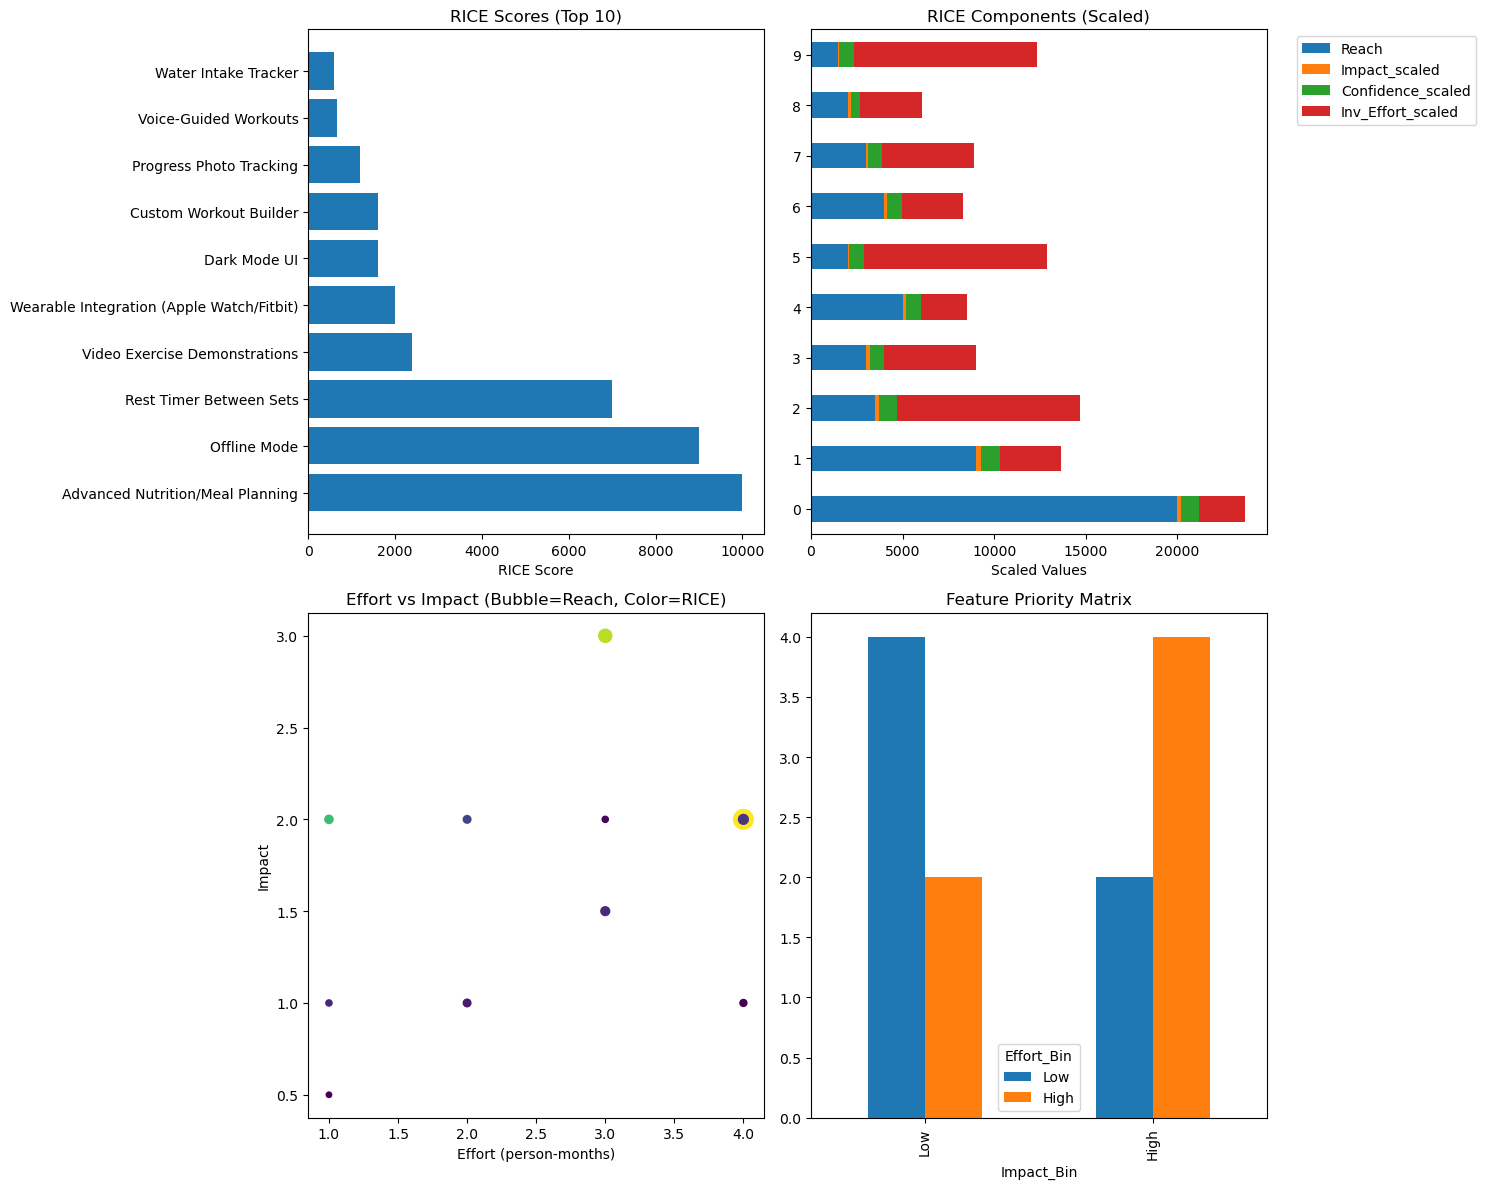


Exported: rice_scores.csv, top5_features.csv
Visualizations saved as visualizations.png


In [9]:
print("="*60)
print("Step 8: VISUALIZATION") 
print("="*60)

plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. RICE Scores bar
top10 = rice_df.head(10)
axes[0,0].barh(range(len(top10)), top10['RICE_Score'])
axes[0,0].set_yticks(range(len(top10)))
axes[0,0].set_yticklabels(top10['Feature'])
axes[0,0].set_title('RICE Scores (Top 10)')
axes[0,0].set_xlabel('RICE Score')

# 2. RICE Components stacked
comp_data = top10[['Reach']].copy()
comp_data['Impact_scaled'] = top10['Impact'] * 100
comp_data['Confidence_scaled'] = top10['Confidence'] * 1000
comp_data['Inv_Effort_scaled'] = (1 / top10['Effort']) * 10000

comp_data[['Reach', 'Impact_scaled', 'Confidence_scaled', 'Inv_Effort_scaled']].plot(
    kind='barh', 
    stacked=True, 
    ax=axes[0,1],
    title='RICE Components (Scaled)'
)
axes[0,1].set_xlabel('Scaled Values')
axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. Effort vs Impact scatter
axes[1,0].scatter(rice_df['Effort'], rice_df['Impact'], s=rice_df['Reach']/100, c=rice_df['RICE_Score'], cmap='viridis')
axes[1,0].set_xlabel('Effort (person-months)')
axes[1,0].set_ylabel('Impact')
axes[1,0].set_title('Effort vs Impact (Bubble=Reach, Color=RICE)')

# 4. Priority Matrix (Impact vs Effort binned)
rice_df['Impact_Bin'] = pd.cut(rice_df['Impact'], bins=2, labels=['Low', 'High'])
rice_df['Effort_Bin'] = pd.cut(rice_df['Effort'], bins=2, labels=['Low', 'High'])
pd.crosstab(rice_df['Impact_Bin'], rice_df['Effort_Bin']).plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Feature Priority Matrix')

plt.tight_layout()
plt.savefig('visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

# Export results
rice_df.to_csv('rice_scores.csv', index=False)
top_5.to_csv('top5_features.csv', index=False)
print("\nExported: rice_scores.csv, top5_features.csv")
print("Visualizations saved as visualizations.png")